# 🏗️ Pretraining at Scale

[Sam Foreman](https://samforeman.me)
(\[[ALCF](https://alcf.anl.gov/about/people/sam-foreman)\](<https://alcf.anl.gov/about/people/sam-foreman>))  
2026-07-22

> **Authors**
>
> Written by [Sam Foreman](https://samforeman.me) for the [Intro to HPC
> Bootcamp](https://intro-hpc-bootcamp.alcf.anl.gov/).

[](https://colab.research.google.com/github/saforem2/intro-hpc-bootcamp/blob/main/docs/03-advanced-llms/1-pretraining-at-scale/index.ipynb)
[](https://github.com/saforem2/intro-hpc-bootcamp/blob/main/content/03-advanced-llms/1-pretraining-at-scale/index.qmd)

You already know *how* to shard a model across many GPUs from [\[01.4\]
Distributed
Training](../../01-neural-networks/4-distributed-training/index.qmd)
(DDP, ZeRO, FSDP, TP, PP, SP, and 3D parallelism) and how to *launch*
those runs from [\[02.1\] Parallel
Training](../../02-llms/1-parallel-training/index.qmd). This lab is
about everything *around* the training loop that decides whether a
thousand-GPU pretraining run is fast or a thousand-GPU space heater:

- **Theme A — Getting your code onto the machine.** At scale, just
  *importing your Python environment* can crash the filesystem.
- **Theme B — Knowing if you’re fast.** Throughput (`tokens/sec`) and
  **MFU** (Model FLOPs Utilization) are the numbers that matter.
- **Theme C — Keeping the GPUs busy.** Efficient collectives and
  communication/computation overlap.
- **Theme D — Feeding the model.** Data mixtures and synthetic data —
  quality vs quantity.

We use [`ezpz`](https://github.com/saforem2/ezpz) for the plumbing and
[`torchtitan`](https://github.com/pytorch/torchtitan) as the reference
pretraining backbone, and we follow the usual **① toy → ② real → ③
scale** arc.

## 🌪️ Theme A: The Import Storm

Here is a problem you never hit on a laptop and never forget once you
hit it at scale.

Your Python environment (`.venv/` or a conda env) lives on a **shared
parallel filesystem** — Lustre on Aurora/Polaris, NFS elsewhere. A
modern ML env is *millions* of small files (`torch` alone is tens of
thousands). When a single `python3 -m torchtitan.train` starts,
`import torch` triggers a storm of `open()` / `stat()` / `read()` calls
against that shared filesystem.

On **one** node this is a minor startup tax. On **hundreds or
thousands** of nodes, every rank does it *at the same time*. The
metadata servers (MDS) that serve those `stat()`s are a shared, finite
resource — and thousands of nodes hammering them simultaneously is a
self-inflicted denial-of-service. This is the **import storm**, and it
can turn a 30-second startup into 20+ minutes of dead time (or crash the
filesystem for everyone else on the machine).

<figure id="fig-import-storm">
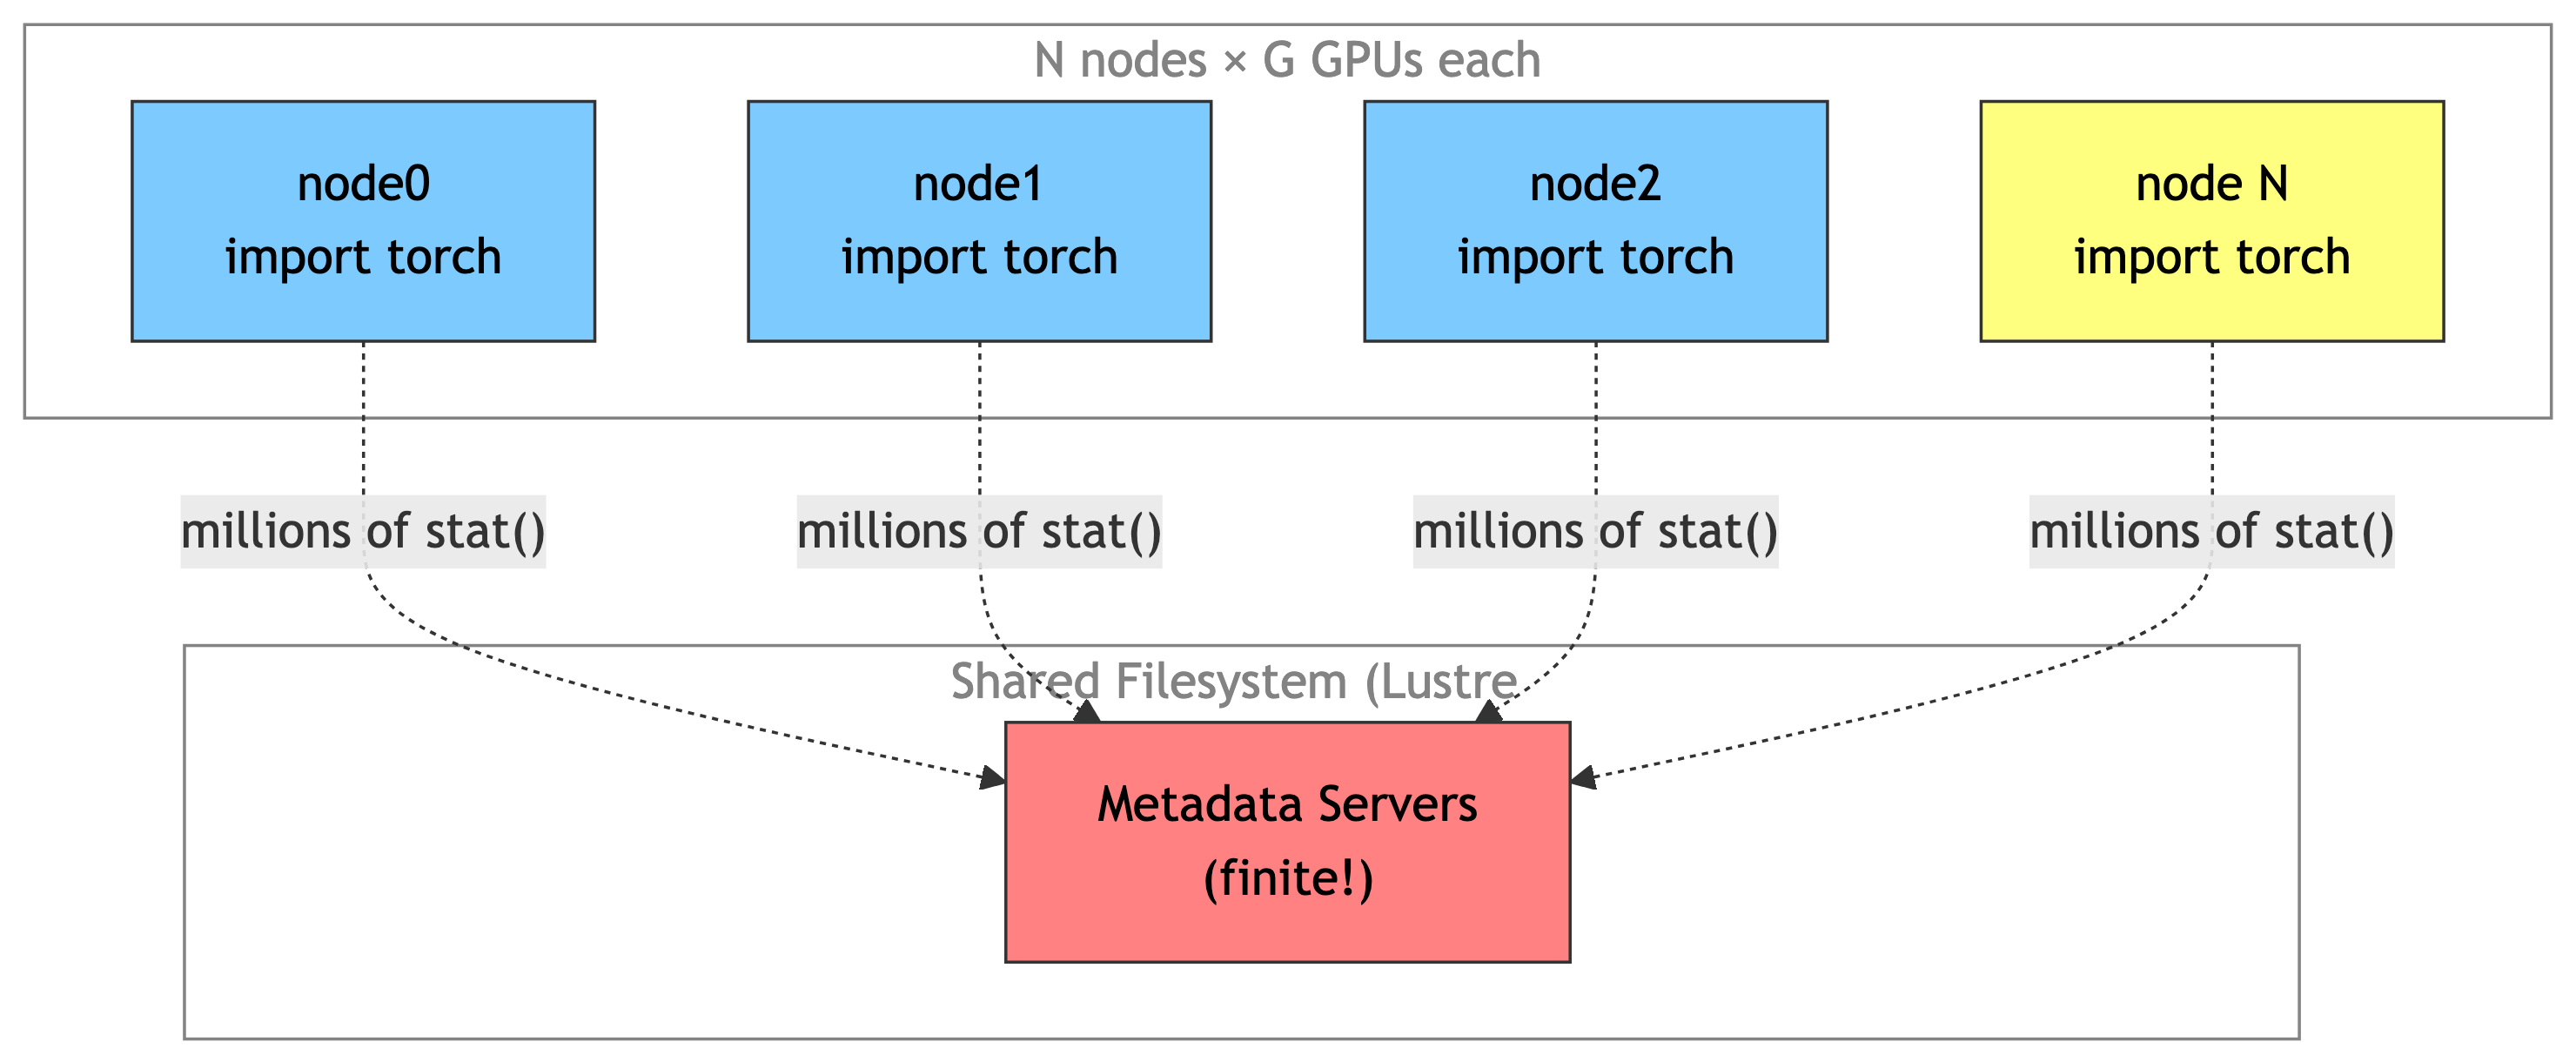
<figcaption>Figure 1: Every rank importing from the same shared
filesystem at once overwhelms the metadata servers — the <em>import
storm</em>.</figcaption>
</figure>

### 🚀 The fix: `ezpz yeet`

The solution is to stop reading the env from Lustre on every node.
Instead:

1.  **Tarball the env once** (`ezpz tar-env`), turning millions of files
    into *one* sequential read for the filesystem.
2.  **Broadcast the tarball to node-local `/tmp/`** on every worker
    (`ezpz yeet`), then extract it there.
3.  Activate `/tmp/.venv` — now every `import` hits fast **node-local
    SSD**, not the shared filesystem.

The clever part is *how* `yeet` distributes the tarball. A naive “copy
from one source to all N nodes” saturates a single node’s network card.
Instead `yeet` uses a **greedy tree fan-out**: the moment any node
finishes receiving the tarball, it *becomes a source* for other nodes.
The number of sources roughly doubles each generation, so wall-clock
time grows like $O(\log N)$ instead of $O(N)$.

<figure id="fig-yeet-tree">
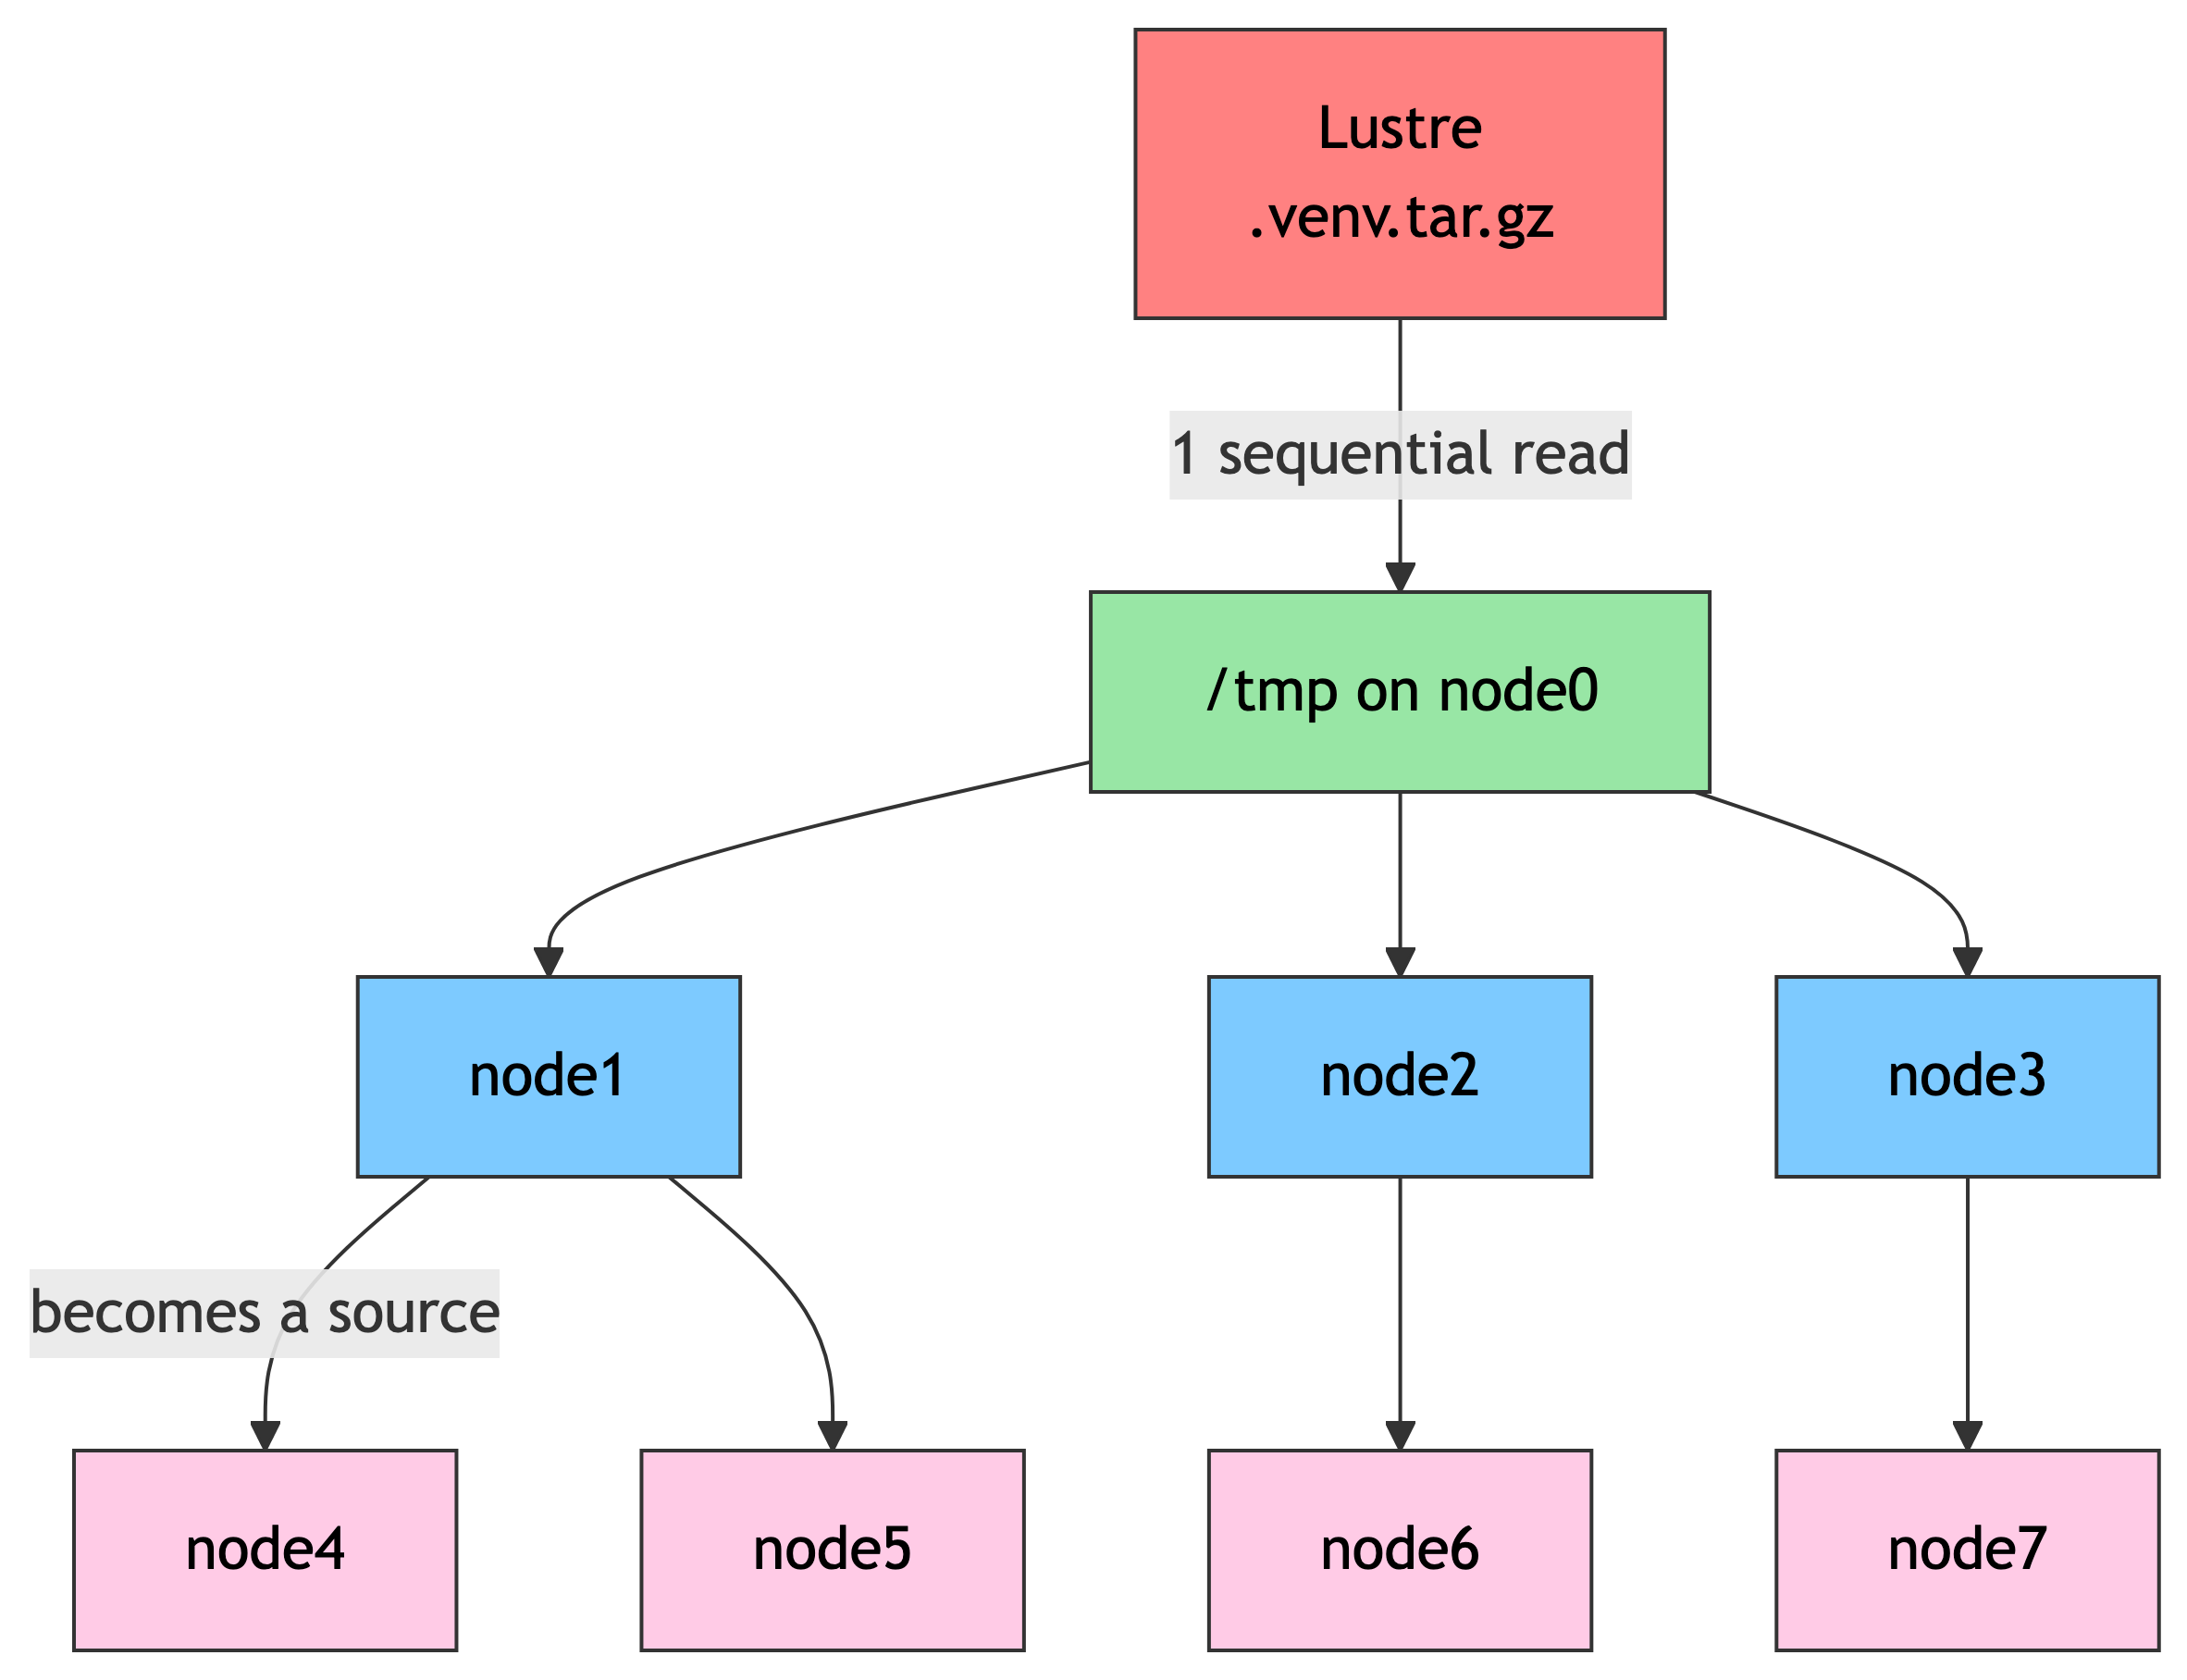
<figcaption>Figure 2: Tree distribution: each finished node becomes a
source, so bandwidth grows with <code>N</code> instead of bottlenecking
on one NIC.</figcaption>
</figure>

The commands (display-only — run these *inside an interactive
allocation*):

``` bash
# 1. Build the tarball ONCE (~3-5 min for a typical ~8 GB env).
#    This turns millions of small files into a single archive next to .venv/
ezpz tar-env

# 2. Broadcast it to /tmp/.venv on every node in the job.
#    --compress = copy one file + extract locally (least metadata I/O).
ezpz yeet .venv.tar.gz --compress

# 3. Activate the node-local copy and launch from there.
deactivate
source /tmp/.venv/bin/activate
```

> **🔬 At DeepSeek-v3 / full-Aurora scale…**
>
> Why is the tarball broadcast **~10× faster** than per-file `rsync` at
> scale? Per-file `rsync` re-`stat()`s every one of the millions of
> files on the *source* (Lustre) side — the exact metadata pressure
> we’re trying to avoid. The tarball turns that into a single sequential
> read, and `yeet`’s tree fan-out handles the network side. Measured on
> Aurora, per-file mode was projected at **1–2 hours** for 256+ nodes;
> the tarball broadcast stays **under 13 minutes even at 4096 nodes**,
> with the per-node amortized cost dropping from 8.7 s/node at N=8 to
> 0.18 s/node at N=4096 (a ~48× efficiency gain).

At scale, a node or two will inevitably fail an SSH/`rsync` step. Rather
than failing the whole job for a spare node, tell `yeet` how many nodes
you actually need:

``` bash
# Allocated 522 nodes, only need 512: proceed as long as ≥ 512 succeed.
ezpz yeet .venv.tar.gz --compress --min-success-nodes 512
# (or as a fraction of the hostfile:  --min-success-fraction 0.95)
```

`yeet` writes the list of failed hosts to
`/tmp/.venv/.ezpz-yeet-failed-nodes.txt` so your launch script can
exclude them.

## 📊 Theme B: Throughput & MFU

Once your code is on the machine, the question becomes: **is it fast?**
Two numbers answer this.

**Throughput** is the intuitive one: **tokens per second**. If you know
your target token budget (Theme D), `tokens/sec` tells you the
wall-clock cost of the whole run.

**MFU (Model FLOPs Utilization)** is the efficiency one. It’s the
fraction of your hardware’s *theoretical* peak compute that your model
actually uses:

$$\mathrm{MFU} = \frac{\text{model FLOPs per second (achieved)}}{\text{peak FLOPs per second (hardware)}}$$

To get the numerator, we need the FLOPs of one training step. The
standard rule-of-thumb (Kaplan et al., and the Chinchilla paper
[arXiv:2203.15556](https://arxiv.org/abs/2203.15556)) is that a forward
**and** backward pass over a dense transformer costs about

$$C \approx 6 \, N \, D$$

FLOPs, where $N$ is the number of (non-embedding) parameters and $D$ is
the number of tokens processed. The factor of 6 is “2 for the forward
pass, 4 for the backward pass.” So:

$$\mathrm{MFU} = \frac{6 \, N \, D}{t_{\text{step}} \times P_{\text{peak}}}$$

where $t_{\text{step}}$ is the wall-clock time for one step and
$P_{\text{peak}}$ is the accelerator’s peak FLOP/s (e.g. ~989 TFLOP/s
BF16 for an H100, ~312 for an A100). Real, well-tuned large pretraining
runs land somewhere around **35–55% MFU**; anything under ~20% usually
means you’re bottlenecked on communication or data loading, not compute.

### ① A toy MFU that really runs

Let’s make this concrete with a tiny example that runs on a laptop CPU.
We time a real (tiny) training step, compute `tokens/sec`, and form an
**MFU-style ratio** by comparing achieved FLOP/s against a *measured*
peak (a big dense matmul on the same machine). Flip `eval: false → true`
and it runs as-is; on a GPU cluster you’d swap the measured peak for
`ezpz.flops.get_peak_flops()`.

In [2]:
import time
import torch

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"

# --- (a) Measure a "peak" via a large dense matmul microbenchmark ---
# 2 * N^3 FLOPs for an (N x N) @ (N x N) matmul.
M = torch.randn(1024, 1024, device=device)
for _ in range(3):  # warmup
    _ = M @ M
n = 20
t0 = time.perf_counter()
for _ in range(n):
    _ = M @ M
dt_mm = (time.perf_counter() - t0) / n
peak_flops = (2 * 1024**3) / dt_mm
print(f"measured peak (dense matmul): {peak_flops / 1e9:.1f} GFLOP/s")

measured peak (dense matmul): 1255.2 GFLOP/s

In [3]:
# --- (b) Time a tiny "language-model-shaped" training step ---
batch, seq, d_model, vocab = 8, 64, 256, 512
tokens_per_step = batch * seq

emb = torch.nn.Embedding(vocab, d_model).to(device)
lm_head = torch.nn.Linear(d_model, vocab).to(device)
params = list(emb.parameters()) + list(lm_head.parameters())
opt = torch.optim.SGD(params, lr=1e-3)

x = torch.randint(0, vocab, (batch, seq), device=device)
y = torch.randint(0, vocab, (batch, seq), device=device)


def train_step():
    opt.zero_grad()
    logits = lm_head(emb(x))
    loss = torch.nn.functional.cross_entropy(logits.view(-1, vocab), y.view(-1))
    loss.backward()
    opt.step()
    return loss


for _ in range(2):  # warmup (exclude graph build / allocation)
    train_step()

n_steps = 20
t0 = time.perf_counter()
for _ in range(n_steps):
    train_step()
dt = (time.perf_counter() - t0) / n_steps

tps = tokens_per_step / dt
print(f"step time  : {dt * 1e3:.2f} ms")
print(f"throughput : {tps:,.0f} tokens/sec")

step time  : 0.98 ms
throughput : 524,400 tokens/sec

In [4]:
# --- (c) Compute a toy MFU-style ratio using the 6*N*D rule ---
# Count the params that actually do matmuls (the linear head dominates here).
N = sum(p.numel() for p in lm_head.parameters())
flops_per_step = 6 * N * tokens_per_step          # 6 * N * D  (fwd + bwd)
achieved_flops = flops_per_step / dt
toy_mfu = 100.0 * achieved_flops / peak_flops

print(f"head params (N)  : {N:,}")
print(f"FLOPs / step     : {flops_per_step:.2e}")
print(f"achieved         : {achieved_flops / 1e9:.2f} GFLOP/s")
print(f"toy MFU          : {toy_mfu:.1f}%")

head params (N)  : 131,584
FLOPs / step     : 4.04e+08
achieved         : 414.02 GFLOP/s
toy MFU          : 33.0%

The toy MFU comes out well under 100% — the tiny step is dominated by
Python / kernel-launch overhead relative to a big dense matmul, which is
*exactly* the intuition MFU is meant to capture: small, comm-heavy, or
overhead-bound work wastes the hardware.

### The real thing: `ezpz.flops.compute_mfu`

In a real run you don’t hand-roll this. `ezpz` ships
[`ezpz.flops`](https://github.com/saforem2/ezpz/blob/main/src/ezpz/flops.py),
which counts FLOPs with PyTorch’s `FlopCounterMode` and knows the peak
BF16 FLOP/s for common accelerators (H100/H200/B200, A100, MI300X, Intel
PVC, …):

In [5]:
import time
import ezpz
from ezpz.flops import try_estimate, compute_mfu

rank = ezpz.setup_torch()                 # returns global rank
device = ezpz.get_torch_device()
model = build_model().to(device)          # your model

# Count FLOPs ONCE (fwd + bwd) for the real (batch, seq) shape.
model_flops = try_estimate(model, input_shape=(batch_size, seq_len))

for step in range(num_steps):
    t0 = time.perf_counter()
    loss = train_step(model, batch)       # fwd + bwd + optimizer.step
    ezpz.synchronize()                    # don't time async kernels early!
    dt = time.perf_counter() - t0

    mfu = compute_mfu(model_flops, dt)    # per-device MFU %, auto peak lookup
    tps = (batch_size * seq_len) / dt
    if rank == 0:
        print(f"step={step} dt={dt:.3f}s tps={tps:,.0f} mfu={mfu:.1f}%")

The bundled `ezpz` examples emit `tflops`, `mfu`, and `tokens_per_sec`
directly when you pass `--profile`:

``` bash
# --profile makes the example estimate model FLOPs and log tflops/mfu/tps.
ezpz launch python3 -m ezpz.examples.hf --profile
```

## 🗣️ Theme C: Efficient Collectives

Every step of data-parallel training ends with an
[**all-reduce**](../../01-neural-networks/4-distributed-training/index.qmd#allreduce)
of gradients; sharded strategies add
[**all-gather**](../../01-neural-networks/4-distributed-training/index.qmd#allgather)
of parameters (FSDP) and reduce-scatter of gradients. You saw these
collectives in
[\[01.4\]](../../01-neural-networks/4-distributed-training/index.qmd) —
here we care about their *cost*.

That cost is paid over the interconnect (NVLink within a node,
InfiniBand / Slingshot between nodes), and it’s implemented by a
**collective communication library**:

- **[NCCL](https://developer.nvidia.com/nccl)** — NVIDIA’s library; the
  default backend on NVIDIA GPUs.
- **[oneCCL](https://www.intel.com/content/www/us/en/developer/tools/oneapi/oneccl.html)**
  — Intel’s equivalent for XPU (Aurora’s PVC GPUs).
- **[torchcomms](https://github.com/pytorch/torchcomms)** — a newer
  PyTorch communications layer aimed at a unified, backend-agnostic API
  for very large scale.

`ezpz` auto-selects the right backend for you
(`ezpz.get_torch_backend()` → `nccl` / `ccl` / `gloo`), so you rarely
set it by hand.

The number that decides whether scaling works is the **comm : compute
ratio**. Each step you do some compute (the FLOPs from Theme B) and some
communication (moving gradients/params). If communication can’t be
hidden behind compute, the GPUs stall — and MFU tanks.

The escape hatch is **communication/computation overlap**: start the
gradient all-reduce for layer $\ell$ *while* still computing the
backward pass for layer $\ell-1$, so the comm is *hidden* behind compute
instead of stacking after it. Modern frameworks (DDP’s gradient
bucketing, FSDP’s prefetching, torchtitan) do this automatically — but
it only helps if there’s enough compute per step to hide the comm
behind. That’s why **bigger per-GPU batches and larger models generally
scale better**: more compute per unit of communication.

> **⏰ Keeping things in sync**
>
> **Computation stalls during communication.** Collectives are
> *blocking*: every rank must call the same collective, in the same
> order, or the ranks that arrive first wait **indefinitely** for the
> stragglers. Keeping the **communication-to-computation ratio small**
> is what makes scaling actually work — it’s the single biggest lever
> between “10% MFU” and “45% MFU” at scale.

## 🍱 Theme D: Data Mixes & Synthetic Data

A pretraining run is only as good as what you feed it. Two decisions
dominate: the **data mixture** (what proportion of each domain) and,
increasingly, **synthetic data** (model-generated training data).

### The data mixture

You don’t train on “the internet” uniformly. You up- or down-weight
domains to shape the model’s capabilities. A representative mixture
(loosely following what Llama, DeepSeek, and
[OLMo](https://allenai.org/olmo) report):

| Domain            | Example sources                      | Weight |
|:------------------|:-------------------------------------|-------:|
| Web / CommonCrawl | filtered CommonCrawl, C4, RefinedWeb |    50% |
| Code              | GitHub, The Stack                    |    20% |
| Academic / STEM   | arXiv, papers, textbooks             |    12% |
| Books / long-form | books, literature                    |    10% |
| Math              | math web, proofs, problem sets       |     5% |
| Reference / Wiki  | Wikipedia, encyclopedic              |     3% |

Table 1: A representative pretraining data mixture (domain → weight).

Why not just “more web”? Because **domain weights are a design choice
about what the model is good at.** Over-weighting code and math
measurably improves reasoning; over-weighting raw web dilutes it.
Reports like DeepSeek’s and OLMo’s show teams running *ablations* —
training small models on candidate mixtures and comparing downstream
evals — before committing to a full-scale run.

### Quality vs quantity

Chinchilla ([arXiv:2203.15556](https://arxiv.org/abs/2203.15556)) told
us *how many* tokens to use: compute-optimally, tokens and parameters
should scale together (~20 tokens per parameter). But its budget assumes
*tokens are interchangeable* — and they aren’t. **A smaller corpus of
high-quality, deduplicated, well-filtered tokens routinely beats a
larger corpus of noisy ones.** In practice, aggressive quality filtering
and dedup (removing near-duplicate documents) is one of the
highest-leverage things you can do — often worth more than adding raw
tokens.

### Synthetic data (conceptual recipe)

When high-quality human data runs out for a domain, teams **generate**
more with a strong existing model — this is how much of the recent gain
in math/code/reasoning data was produced. The core loop (display-only
pseudo-code):

In [6]:
# Conceptual synthetic-data generation loop. NOT runnable here — this is
# the *shape* of the pipeline, not a drop-in implementation.
from your_pipeline import teacher_model, seed_prompts, verify

synthetic = []
for prompt in seed_prompts:                      # e.g. seed problems / topics
    candidates = teacher_model.generate(          # strong model = "teacher"
        prompt, n=8, temperature=0.9,
    )
    for c in candidates:
        # QUALITY GATE is the whole game: keep only what passes a check.
        #   - math/code: execute & test, or verify against ground truth
        #   - general:   LLM-as-judge, dedup, toxicity/PII filters
        if verify(prompt, c):
            synthetic.append({"prompt": prompt, "completion": c})

# Deduplicate against itself AND against the real corpus before mixing in.
synthetic = dedup(synthetic)
# Blend as just another weighted domain in @tbl-data-mix (start small!).

> **🧪 Synthetic data is not free tokens**
>
> Synthetic data amplifies whatever the teacher already knows; without a
> real **verification/filtering** step it degrades diversity and can
> cause *model collapse* (each generation drifting toward the model’s
> own biases). The verifier — unit tests for code, a checker for math,
> dedup + judge for prose — is what makes synthetic data *add* signal
> instead of noise. Treat it as a small, carefully-gated slice of the
> mixture, not a firehose.

## ② The Real Thing: Reading a Training Log

Put Themes B and C together and this is what a healthy
`torchtitan`-style pretraining log looks like on a GPU cluster
(display-only excerpt). Watch `tps` and `mfu` — they’re your live
scaling report card:

``` bash
[rank0] step=  10  loss=8.214  lr=1.20e-04  dt=0.842s  tps=311,900  tflops=402.1  mfu=40.7%
[rank0] step=  20  loss=7.019  lr=2.40e-04  dt=0.839s  tps=312,900  tflops=403.5  mfu=40.8%
[rank0] step=  30  loss=6.447  lr=3.60e-04  dt=0.851s  tps=308,600  tflops=397.9  mfu=40.2%
[rank0] step=  40  loss=6.088  lr=4.80e-04  dt=0.838s  tps=313,400  tflops=404.1  mfu=40.9%
[rank0] step=  50  loss=5.902  lr=6.00e-04  dt=0.844s  tps=311,000  tflops=401.0  mfu=40.6%
```

Reading it:

- **`loss` falling smoothly** → optimization is healthy.
- **`tps` and `mfu` flat and high (~40%)** → compute-bound, comm
  well-hidden. This is what “good” looks like.
- If instead `mfu` were ~12% and `dt` jumped around, you’d suspect a
  **comm:compute** problem (Theme C) or data-loading stalls — not a
  model bug.

> **🔬 At DeepSeek-v3 scale…**
>
> `mfu` is the metric that pays for itself. Going from 25% → 40% MFU on
> a run that would take 60 days is ~22 days saved — pure wall-clock (and
> dollars, and carbon). At frontier scale, a few points of MFU is worth
> an entire engineering team’s quarter.

## ③ Scale It Up: Launch a Pretraining Sweep

Now the full picture: distribute the env with `yeet`, then launch a
`torchtitan` pretraining run across `N` nodes with `ezpz launch`. All
commands are display-only — run them inside an interactive allocation
(or a job script).

``` bash
# --- 0. Inside an interactive allocation (PBS shown; ezpz also handles SLURM) ---
qsub -A <project> -q debug -l select=8 -l walltime=01:00:00 -I

# --- 1. Build env once against a Python that exists on every node ---
source <(curl -fsSL https://bit.ly/ezpz-utils) && ezpz_setup .venv
uv pip install "git+https://github.com/saforem2/ezpz"
# ... plus torchtitan + torch for your system ...

# --- 2. Beat the import storm: tarball + broadcast to node-local /tmp ---
ezpz tar-env
ezpz yeet .venv.tar.gz --compress --min-success-nodes 8
deactivate && source /tmp/.venv/bin/activate

# --- 3. Sanity-check the distributed setup (NOT python3 -m ezpz.test_dist) ---
ezpz test

# --- 4. Launch torchtitan pretraining across all nodes in the job ---
#     ezpz auto-detects PBS->mpiexec / SLURM->srun; no mpirun -n $NGPUS needed.
ezpz launch python3 -m torchtitan.train \
    --job.config_file ./train_configs/llama3_8b.toml \
    --training.steps 100 \
    --metrics.log_freq 10 \
    --checkpoint.enable --checkpoint.interval 50 \
    --profile
```

### 🧭 The node-count sweep

To *see* scaling, run the same config at several node counts and record
`tps` and `mfu` from the logs:

``` bash
# Repeat step 4 for a few node counts (re-qsub or re-yeet as the alloc grows).
# Keep the per-GPU batch size FIXED so you're measuring scaling, not batch size.
for N in 1 2 4 8; do
    ezpz launch --hostfile /tmp/hostfile-${N}nodes \
        python3 -m torchtitan.train \
        --job.config_file ./train_configs/llama3_8b.toml \
        --training.steps 50 --metrics.log_freq 10 --profile \
        2>&1 | tee sweep_${N}nodes.log
done
```

Then extract the steady-state numbers and plot them. Two curves tell the
whole story:

1.  **`tokens/sec` vs node count** — ideally a straight line (perfect
    *weak scaling*). Bending below the line = your comm:compute ratio
    (Theme C) is catching up with you.
2.  **`MFU` vs node count** — ideally flat. A downward slope means each
    added node buys less useful compute — the classic scaling wall.

A quick sketch of the plot you’re aiming for (runs at build time with
dummy numbers — replace with your measured sweep):

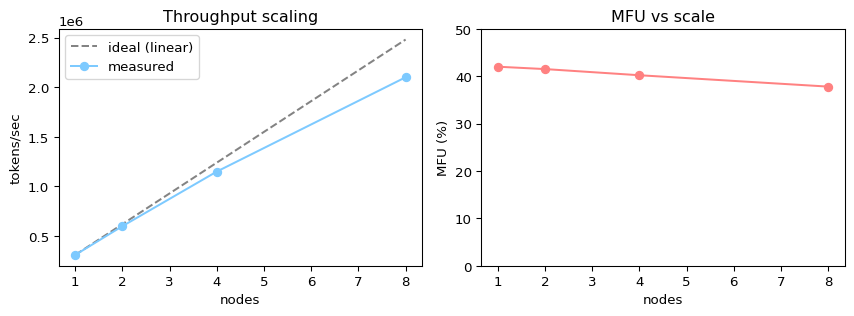

In [7]:
import matplotlib.pyplot as plt

nodes = [1, 2, 4, 8]
tps = [3.1e5, 6.0e5, 1.15e6, 2.1e6]     # measured tokens/sec (example)
mfu = [42.0, 41.5, 40.2, 37.8]          # measured MFU %      (example)
ideal = [tps[0] * n for n in nodes]     # perfect linear scaling reference

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.4))
ax1.plot(nodes, ideal, "--", color="#838383", label="ideal (linear)")
ax1.plot(nodes, tps, "o-", color="#7DCAFF", label="measured")
ax1.set(xlabel="nodes", ylabel="tokens/sec", title="Throughput scaling")
ax1.legend()

ax2.plot(nodes, mfu, "o-", color="#ff8181")
ax2.set(xlabel="nodes", ylabel="MFU (%)", title="MFU vs scale", ylim=(0, 50))
fig.tight_layout()
plt.show()

## 🎒 Homework

Submit *proof* that you were able to distribute an environment and run a
pretraining sweep, and report what you found.

1.  **Beat the import storm.** Inside an allocation, run `ezpz tar-env`
    then `ezpz yeet .venv.tar.gz --compress`. Note the wall-clock
    reported by `yeet` and the node count.
2.  **Run a small sweep.** Launch the same (small) `torchtitan` — or
    `ezpz.examples.hf --profile` — config at **at least 2 different node
    counts** with a fixed per-GPU batch size and `--profile` enabled.
3.  **Report MFU vs node count.** From your logs, extract steady-state
    `tokens/sec` and `mfu` at each node count and either paste the table
    or plot the two curves from the sweep section. One or two sentences:
    is throughput scaling linearly? Is MFU holding up?

Where *proof* can be any of:

- The contents printed to your terminal during the run (the `tps` /
  `mfu` lines).
- A path to a logfile on the ALCF/NERSC filesystems.
- A screenshot of the run output, a plot, or a W&B Run/Report showing
  `tokens_per_sec` and `mfu`.
- Anything that clearly shows you distributed the env and ran the sweep.

## 📚 References

- [`ezpz` — `yeet`
  docs](https://github.com/saforem2/ezpz/blob/main/docs/cli/yeet.md) and
  [`ezpz.flops`](https://github.com/saforem2/ezpz/blob/main/src/ezpz/flops.py)
- [`torchtitan`](https://github.com/pytorch/torchtitan) — PyTorch-native
  pretraining reference
- Hoffmann et al., *Training Compute-Optimal Large Language Models*
  (Chinchilla), [arXiv:2203.15556](https://arxiv.org/abs/2203.15556)
- [OLMo](https://allenai.org/olmo) and the Dolma data report — open
  data-mixture and curation details
- [\[01.4\] Distributed
  Training](../../01-neural-networks/4-distributed-training/index.qmd)
  and [\[02.1\] Parallel
  Training](../../02-llms/1-parallel-training/index.qmd)

Last updated: 2026-07-22 10:04